# ICS 2405: Knowledge-Based Systmes
## evalaution of classification models:


> ##### CONTEXT - a true novel multiclass problem:  
 > this involved evaluation techniques that are appropriate for classifiers.

In [1]:
# setup
from mlwpy import *
%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import (datasets, model_selection as skms, linear_model, metrics, neighbors, naive_bayes)

import sklearn.preprocessing as skpre
import sklearn.multiclass as skmulti 

## dataset:

The data(set) comes from:
> Cortez, P. and Silva, A. “Using Data Mining to Predict Secondary School Student  
> Performance.” In: A. Brito and J. Teixeira (eds), Proceedings of 5th FUture BUsiness
> TEChnology Conference (FUBUTEC 2008), pp. 5-12, Porto, Portugal, April, 2008,
EUROSIS.


---
from UCI data repository: [https://archive.ics.uci.edu/ml/datasets/student+performance](https://archive.ics.uci.edu/ml/datasets/student+performance).

the data measures the student achievement in two secondary education subjects: **math**
and **language**. the two subjects are described in different CSV files; we are only going to
look at the math data.  
> #### attributes:  
> the data attributes - student `grades`, `demographic`, `social`,
and `school-related features` collected by using school reports and questionnaires.
>
> #### preprocessing:  
> - (1) removed non-numerical features and
> - (2) produce a discrete target class for classification.

In [2]:
student_df = pd.read_csv('data/portugese_student_numeric_discrete.csv')
student_df['grade'] = pd.Categorical(student_df['grade'],
                                     categories=['low', 'mid', 'high'],
                                     ordered=True)

In [3]:
student_ftrs = student_df[student_df.columns[:-1]]
student_tgt = student_df['grade'].cat.codes

## 3-NN classifier 

## 1-accuracy:
if the target classes aren’t too unbalanced, we might be OK with accuracy.

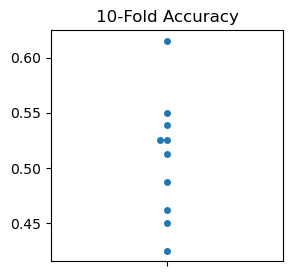

In [4]:
fig,ax = plt.subplots(1, 1, figsize=(3, 3))

model = neighbors.KNeighborsClassifier(3)
cv_auc = skms.cross_val_score(model, student_ftrs, student_tgt, scoring='accuracy', cv=10)

ax = sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold Accuracy');

### 2 - precision
we’ll use `macro` averaging in here and pass it as an argument to a `make_scorer` call.

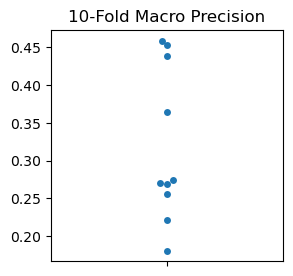

In [5]:
model = neighbors.KNeighborsClassifier(3)
my_scorer = metrics.make_scorer(metrics.precision_score, average='macro')

cv_auc = skms.cross_val_score(model, student_ftrs, student_tgt, scoring=my_scorer, cv=10)

fig,ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold Macro Precision');

### 3- Hand and Till M evaluator:

In [14]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import itertools

def hand_and_till_M_statistic(test_tgt, test_probs, weighted=False):
    """
    Calculate Hand & Till M statistic for multiclass AUC.
    
    Parameters:
    -----------
    test_tgt : array-like, shape (n_samples,)
        True class labels
    test_probs : array-like, shape (n_samples, n_classes)
        Predicted probabilities for each class
    weighted : bool, default=False
        Whether to weight by proportion of examples in each class pair
    
    Returns:
    --------
    M : float
        Hand & Till M statistic (0.5 to 1.0)
    """
    
    def auc_helper(truth, probs):
        """Helper to compute AUC for binary classification"""
        fpr, tpr, _ = roc_curve(truth, probs)
        return auc(fpr, tpr)
    
    # get unique classes
    classes = np.unique(test_tgt)
    n_classes = len(classes)
    
    # binarize labels for easy masking
    indicator = label_binarize(test_tgt, classes=classes)
    
    avg_auc_sum = 0.0
    
    # iterate over all pairs of classes
    for i, j in itertools.combinations(classes, 2):
        # get mask for examples belonging to either class i or j
        # sum to act like logical OR
        ij_indicator = indicator[:, [i, j]].sum(axis=1, dtype=bool)
        
        # get subset for this pair
        ij_probs = test_probs[ij_indicator][:, [i, j]]
        ij_test_tgt = test_tgt[ij_indicator]
        
        # compute AUC in both directions
        auc_ij = auc_helper(ij_test_tgt == i, ij_probs[:, 0])  # i positive, j negative
        auc_ji = auc_helper(ij_test_tgt == j, ij_probs[:, 1])  # j positive, i negative
        
        # Average for this pair
        avg_auc_ij = (auc_ij + auc_ji)
        
        # Apply weighting if requested
        if weighted:
            avg_auc_ij *= ij_indicator.sum() / len(test_tgt)
        
        avg_auc_sum += avg_auc_ij
    
    # final M statistic
    M = avg_auc_sum / (n_classes * (n_classes - 1))
    return M

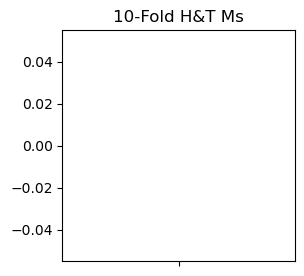

In [15]:
htm_scorer = metrics.make_scorer(hand_and_till_M_statistic, needs_proba=True)

cv_auc = skms.cross_val_score(model, student_ftrs, student_tgt,
                              scoring=htm_scorer, cv=10)

fig,ax = plt.subplots(1, 1, figsize=(3, 3))
sns.swarmplot(cv_auc, orient='v')
ax.set_title('10-Fold H&T Ms');

### compare a few different classifiers with a few different metrics:

In [17]:
classifiers = {'base' : dummy.DummyClassifier(strategy="most_frequent"),
               'gnb' : naive_bayes.GaussianNB(),
               '3-NN' : neighbors.KNeighborsClassifier(n_neighbors=10),
               '10-NN' : neighbors.KNeighborsClassifier(n_neighbors=3)}

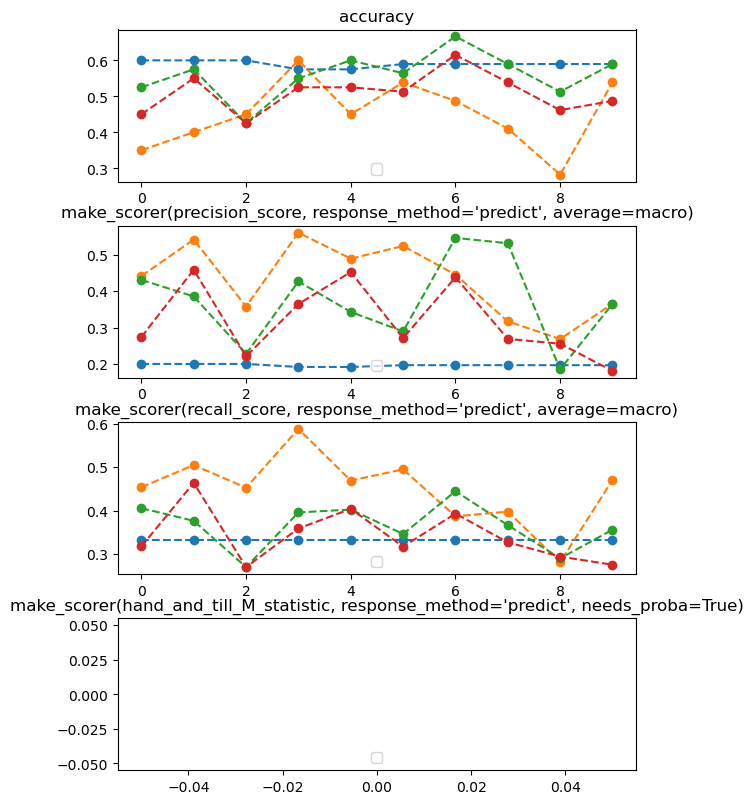

In [18]:
macro_precision = metrics.make_scorer(metrics.precision_score, average='macro')

macro_recall = metrics.make_scorer(metrics.recall_score, average='macro')
htm_scorer = metrics.make_scorer(hand_and_till_M_statistic, needs_proba=True)

msrs = ['accuracy', macro_precision, macro_recall, htm_scorer]

fig, axes = plt.subplots(len(msrs), 1, figsize=(6, 2*len(msrs)))
fig.tight_layout()

for mod_name, model in classifiers.items():
    # abbreviate
    cvs = skms.cross_val_score
    cv_results = {msr:cvs(model, student_ftrs, student_tgt,
                          scoring=msr, cv=10) for msr in msrs}

    for ax, msr in zip(axes, msrs):
        msr_results = cv_results[msr]
        my_lbl = "{:12s} {:.3f} {:.2f}".format(mod_name,
                                               msr_results.mean(),
                                               msr_results.std())
        ax.plot(msr_results, 'o--')
        ax.set_title(msr)
        # uncomment to see summary stats (clutters plots)
        ax.legend(loc='lower center')

#### comment: 
it appears we made a pretty hard problem for ourselves. the preprocessing done - throwing
out features and discretizing, we’ve turned this into a very hard problem...  
thus accuracy, precision, and recall all seem to be pretty downright awful. that cautions us in our interpretation of the `Hand
and Till M` values. a few folds of `GNB` have some values that aren’t awful, but half of the fold values for GNB end up near 0.6. we know things aren’t good, but there is a glimmer of hope—maybe we do well on
some classes, but just poorly overall?

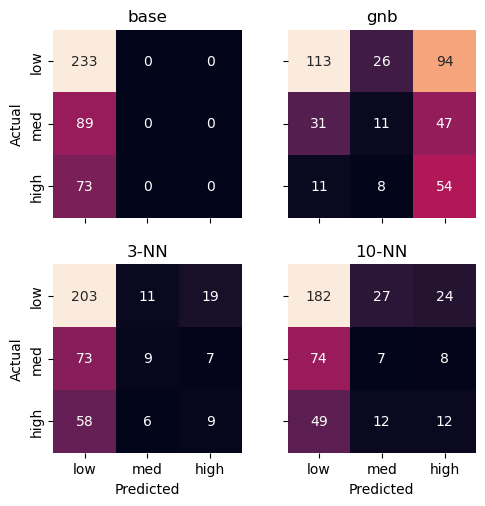

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(5, 5), sharex=True, sharey=True)
fig.tight_layout()

for ax, (mod_name, model) in zip(axes.flat, classifiers.items()):
    preds = skms.cross_val_predict(model, student_ftrs, student_tgt, cv=10)

    cm = metrics.confusion_matrix(student_tgt, preds)
    sns.heatmap(cm, annot=True, ax=ax,
                cbar=False, square=True, fmt="d", 
                xticklabels=['low', 'med', 'high'],
                yticklabels=['low', 'med', 'high'])

    ax.set_title(mod_name)

axes[1, 0].set_xlabel('Predicted')
axes[1, 1].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[1, 0].set_ylabel('Actual');